In [1]:
import numpy as np

# =========================
# PARAMETERS (SI)
# =========================
q = 1.6e-19
m = 3.44e-25
B = 0.2

H = 0.15
L = 0.25
L_star = 0.35

Tmax = 2.5e-4

# field amplitude (to tune)
f0 = 70   # V

# constraints
Emax = 200.0
alpha = 0.1
G = alpha * q * B**2 / m

# =========================
# GEOMETRY
# =========================
def theta(x, y):
    return np.arctan2(y, (L_star - x))

def r(x, y):
    return np.sqrt((L_star - x)**2 + y**2) + 1e-12

theta_max = np.arctan((H/2) / L_star)

# =========================
# FIELD: f(theta) = f0
# =========================
def E_field(x, y):
    rr = r(x, y)

    Ex = f0 * y / rr**2
    Ey = f0 * (L_star - x) / rr**2

    return Ex, Ey

def E_mag(x, y):
    Ex, Ey = E_field(x, y)
    return np.sqrt(Ex**2 + Ey**2)

# =========================
# NUMERICAL GRADIENT
# =========================
def grad_E(x, y, dx=1e-4, dy=1e-4):
    E0 = E_mag(x, y)
    dEdx = (E_mag(x + dx, y) - E0) / dx
    dEdy = (E_mag(x, y + dy) - E0) / dy
    return np.sqrt(dEdx**2 + dEdy**2)

# =========================
# TRAJECTORY (ExB drift)
# =========================
def simulate_particle(x0, y0, dt=1e-7):
    x, y = x0, y0
    t = 0.0

    crossed = False
    y_at_L = None

    while t < Tmax:
        Ex, Ey = E_field(x, y)

        vx = Ey / B
        vy = -Ex / B

        x += vx * dt
        y += vy * dt
        t += dt

        if (not crossed) and (x >= L):
            crossed = True
            y_at_L = y

    return x, y, crossed, y_at_L

# =========================
# RUN TRAJECTORIES
# =========================
print("=== Particle simulation ===")

x1, y1, c1, _ = simulate_particle(0.0, 0.0)
x2, y2, c2, yL = simulate_particle(0.0, H/2)

print(f"Center particle: x_final = {x1:.4f}, crossed = {c1}")
print(f"Edge particle:   x_final = {x2:.4f}, crossed = {c2}")
print(f"h (from traj):   {yL:.6f} m")

# =========================
# TIME CHECK (analytic)
# =========================
def transport_time(theta_val):
    # T = B (L*L - L^2/2) / f0
    return B * (L_star * L - L**2 / 2) / f0

T_test = transport_time(0.0)
print(f"\nAnalytic T ≈ {T_test:.3e} s (should be < Tmax={Tmax:.3e})")

# =========================
# GRID CONSTRAINT CHECK
# =========================
print("\n=== Field constraints ===")

Nx, Ny = 120, 120

xs = np.linspace(0, L, Nx)
ys = np.linspace(0, H/2, Ny)

E_max_val = 0.0
gradE_max_val = 0.0

for x in xs:
    for y in ys:
        # triangular domain
        if y > (H/(2*L_star)) * (L_star - x):
            continue

        Em = E_mag(x, y)
        Gm = grad_E(x, y)

        E_max_val = max(E_max_val, Em)
        gradE_max_val = max(gradE_max_val, Gm)

print(f"Max |E|:     {E_max_val:.2f} V/m (limit {Emax})")
print(f"Max |gradE|: {gradE_max_val:.2f} V/m^2 (limit {G})")

print("\nConstraints:")
print(f"|E| OK?        {E_max_val < Emax}")
print(f"|gradE| OK?    {gradE_max_val < G}")

=== Particle simulation ===
Center particle: x_final = -0.0292, crossed = True
Edge particle:   x_final = 0.2426, crossed = True
h (from traj):   0.021397 m

Analytic T ≈ 1.607e-04 s (should be < Tmax=2.500e-04)

=== Field constraints ===
Max |E|:     700.00 V/m (limit 200.0)
Max |gradE|: 7007.01 V/m^2 (limit 1860.4651162790701)

Constraints:
|E| OK?        False
|gradE| OK?    False


In [2]:
import numpy as np

# =========================
# PARAMETERS (SI)
# =========================
q = 1.6e-19
m = 3.44e-25
Bz = 0.2

H = 0.15
L = 0.25
L_star = 0.35

Tmax = 2.5e-4

# tuned field
f0 = 70.0

# =========================
# DERIVED
# =========================
omega_c = q * Bz / m
Tgyro = 2 * np.pi / omega_c

# resolve gyro motion
dt = Tgyro / 200   # ~50 steps per gyration
Nsteps = int(Tmax / dt)

print(f"dt = {dt:.2e}, steps = {Nsteps}")

# =========================
# FIELD
# =========================
def E_field(x, y):
    dx = L_star - x
    r2 = dx**2 + y**2 + 1e-16

    Ex = f0 * y / r2
    Ey = f0 * dx / r2

    return Ex, Ey

def B_field():
    return np.array([0.0, 0.0, Bz])

# =========================
# BORIS PUSHER
# =========================
def boris_push(x, v, dt):
    Ex, Ey = E_field(x[0], x[1])
    E = np.array([Ex, Ey, 0.0])
    B = B_field()

    # half acceleration
    v_minus = v + (q * E / m) * (dt / 2)

    # rotation
    t = (q * B / m) * (dt / 2)
    t_mag2 = np.dot(t, t)
    s = 2 * t / (1 + t_mag2)

    v_prime = v_minus + np.cross(v_minus, t)
    v_plus = v_minus + np.cross(v_prime, s)

    # second half acceleration
    v_new = v_plus + (q * E / m) * (dt / 2)

    # position update
    x_new = x + v_new * dt

    return x_new, v_new

# =========================
# INITIAL PARTICLES
# =========================
N = 100

ys0 = np.linspace(-H/2, H/2, N)

particles = []
for y0 in ys0:
    x = np.array([0.0, y0, 0.0])
    # random gyro phase
    phi = np.random.uniform(0, 2*np.pi)

    # choose perpendicular speed scale (important!)
    Ec = f0 / (L_star - L)
    v_perp = Ec / B   # or tune (see below)

    vx = v_perp * np.cos(phi)
    vy = v_perp * np.sin(phi)

    v = np.array([vx, vy, 0.0])
    particles.append((x, v))

# =========================
# SIMULATION
# =========================
cross_y = np.full(N, np.nan)
crossed = np.zeros(N, dtype=bool)

for step in range(Nsteps):
    for i in range(N):
        x, v = particles[i]

        x_new, v_new = boris_push(x, v, dt)

        # detect crossing x = L
        if (not crossed[i]) and (x[0] < L) and (x_new[0] >= L):
            crossed[i] = True

            # linear interpolation for better accuracy
            alpha = (L - x[0]) / (x_new[0] - x[0] + 1e-16)
            y_cross = x[1] + alpha * (x_new[1] - x[1])
            cross_y[i] = y_cross

        particles[i] = (x_new, v_new)

# =========================
# RESULTS
# =========================
final_x = np.array([p[0][0] for p in particles])

all_crossed = np.all(final_x > L)

valid_y = cross_y[~np.isnan(cross_y)]

print("\n=== Results ===")
print(f"All particles reached x > L? {all_crossed}")

if len(valid_y) > 0:
    print(f"max(|y - mean(y)|) at L: {np.max(np.absolute(valid_y - valid_y.mean())):.6f} m")
    print(f"std(y at L): {np.std(valid_y):.6f} m")
else:
    print("No crossings recorded!")

# Optional: debug fraction
print(f"Crossed count: {np.sum(crossed)}/{N}")

dt = 3.38e-07, steps = 740

=== Results ===
All particles reached x > L? False
max(|y - mean(y)|) at L: 0.081544 m
std(y at L): 0.024929 m
Crossed count: 100/100


In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# =========================
# CONSTANTS (SI)
# =========================
q = 1.6e-19
m = 3.44e-25
B = 0.2

n = 5e18
Z_length = 0.75

# =========================
# TRAJECTORY (time-based)
# =========================
def simulate_gc_(L_star, f0, y0, Tmax):

    dt = Tmax / 400
    x, y = 0.0, y0

    xs, ys = [x], [y]

    t = 0.0
    while t < Tmax:

        dx = L_star - x
        r2 = dx**2 + y**2 + 1e-16

        vx = (f0 * dx / r2) / B
        vy = -(f0 * y / r2) / B

        x += vx * dt
        y += vy * dt

        xs.append(x)
        ys.append(y)

        t += dt

    return np.array(xs), np.array(ys)

def boris_push_(x, v, dt, f0, L_star):
    dx = L_star - x[0]
    r2 = dx**2 + x[1]**2 + 1e-16

    Ex = f0 * x[1] / r2
    Ey = f0 * dx / r2

    E = np.array([Ex, Ey, 0.0])
    Bb = np.array([0.0, 0.0, B])

    # half accel
    v_minus = v + (q * E / m) * (dt/2)

    # rotation
    t = (q * Bb / m) * (dt/2)
    s = 2 * t / (1 + np.dot(t,t))

    v_prime = v_minus + np.cross(v_minus, t)
    v_plus = v_minus + np.cross(v_prime, s)

    # second half accel
    v_new = v_plus + (q * E / m) * (dt/2)

    x_new = x + v_new * dt

    return x_new, v_new

# =========================
# BORIS SIMULATION
# =========================
def simulate_boris_(L_star, f0, y0, Tmax):

    omega_c = q * B / m
    Tgyro = 2*np.pi / omega_c
    dt = Tgyro / 50

    Nsteps = int(Tmax / dt)

    phases = np.linspace(0, 2*np.pi, 10)

    trajectories = []

    # characteristic velocity scale
    E0 = f0 / (L_star + 1e-6)
    v_perp = 0 #E0 / B

    for phi in phases:

        x = np.array([0.0, y0, 0.0])
        v = np.array([
            v_perp * np.cos(phi),
            v_perp * np.sin(phi),
            0.0
        ])

        xs, ys = [x[0]], [x[1]]

        for _ in range(Nsteps):
            x, v = boris_push_(x, v, dt, f0, L_star)
            xs.append(x[0])
            ys.append(x[1])

        trajectories.append((np.array(xs), np.array(ys)))

    return trajectories


# =========================
# MAIN FUNCTION
# =========================

y0_cm_prev = Tmax_ms_prev = 0
wmin = 5000
L_star_best = 0
f0_best = 0
def plot_system(L_star_cm=40, f0=70, y0_cm=15, Tmax_ms=0.25):
    L_star = L_star_cm / 100
    y0 = y0_cm / 100
    Tmax = Tmax_ms / 1000  # ms → s

    
        
    def get_values(L_star, f0, y0, Tmax):

        xs, ys = simulate_gc_(L_star, f0, y0, Tmax)

        # field + FLR
        r = np.sqrt((L_star - xs)**2 + ys**2)
        E = f0 / r
        rho = m * E / (q * B**2)

        y_upper = ys + rho
        y_lower = ys - rho

        i_max = np.argmax(E > 2000)
        if i_max == 0:
            i_max = len(xs) + 1
            
        # final values
        imin = np.argmin(y_upper[:i_max])
        xL = xs[imin]
        yL = ys[imin]
        EL = E[imin]
        rhoL = rho[imin]

        return xs, ys, y_upper, y_lower, xL, yL, EL, rhoL, i_max

    xs, ys, y_upper, y_lower, xL, yL, EL, rhoL, i_max = get_values(L_star, f0, y0, Tmax)
    gradE = f0 / ((L_star - xL)**2)
    alpha = gradE * m / (q * B**2)

    # mass flow
    vx = EL / B
    flow = m * n * vx * (2*y0) * Z_length
    flow_g_h = flow * 1000 * 3600

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=(7,4))

    boris_trajs = simulate_boris_(L_star, f0, y0, Tmax)
    # Boris particles
    for bx, by in boris_trajs:
        p = plt.plot(bx*100, by*100, 'b.', alpha=1)
    p[0].set_label("Boris")

    plt.plot(xs*100, ys*100, 'k--', label='Guiding center')
    plt.plot(xs[:i_max]*100, y_upper[:i_max]*100, 'r', label='± Larmor envelope')
    plt.plot(xs[:i_max]*100, y_lower[:i_max]*100, 'r')

    plt.axvline(xL*100, linestyle=':', color='gray')

    plt.xlim(0, 50)
    plt.ylim(-5, 20)

    plt.xlabel("x (cm)")
    plt.ylabel("y (cm)")
    plt.grid()
    plt.legend()

    plt.title("Time-based guiding center trajectory")

    # =========================
    # TEXT ON PLOT
    # =========================
    text = (
        f"L = {xL*100:.1f} cm\n"
        f"y = {yL*100:.2f} cm\n"
        f"y + ρ = {(yL+rhoL)*100:.2f} cm\n"
        f"E ≈ {EL:.0f} V/m\n"
        f"α ≈ {alpha:.3f}\n"
        f"ṁ ≈ {flow_g_h:.1f} g/h"
    )

    plt.text(
        0.02, 0.02, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    global y0_cm_prev, Tmax_ms_prev, wmin, L_star_best, f0_best
    if y0_cm_prev != y0_cm or Tmax_ms_prev != Tmax_ms:
        wmin = np.inf
        for L_star in np.arange(10, 80, 1) / 100:
            for f0 in np.arange(10, 200, 5):
                xs, ys, y_upper, y_lower, xL, yL, EL, rhoL, i_max = get_values(L_star, f0, y0, Tmax)
                if yL + rhoL < wmin and f0 / ((L_star - xL)**2) * m / (q * B**2) < 0.5:
                    wmin = yL + rhoL
                    L_star_best = L_star
                    f0_best = f0
    
    text = (
        f"Optimal\n"
        f"y + ρ = {(wmin)*100:.2f} cm\n"
        f"L* = {L_star_best * 100:.0f}\n"
        f"f0 = {f0_best:.0f}"
    )

    plt.text(
        0.98, 0.02, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    y0_cm_prev = y0_cm
    Tmax_ms_prev = Tmax_ms
    plt.show()

# =========================
# INTERACTIVE
# =========================
interact(
    plot_system,
    L_star_cm=(10, 80, 1),
    f0=(10, 200, 5),
    y0_cm=(5, 25, 1),
    Tmax_ms=(0.05, 0.5, 0.01),
);

interactive(children=(IntSlider(value=40, description='L_star_cm', max=80, min=10), IntSlider(value=70, descri…

In [4]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def plot_system(L_star_cm=40, f0=70, H_cm=30, L_cm=30):
    # Convert cm to m for calculations
    L_star = L_star_cm / 100
    L = L_cm / 100
    H = H_cm / 100
    
    # Create Grid
    nx = ny = 200
    x = np.linspace(0, L, nx)
    y = np.linspace(-H/2, H/2, ny)
    X, Y = np.meshgrid(x, y)
    
    # 2. Vectorized Math
    dx = L_star - X
    r2 = dx**2 + Y**2 + 1e-12
    r_inv = 1.0 / np.sqrt(r2)
    r2_inv = 1.0 / r2
    r3_inv = r_inv * r2_inv
    
    # E-field
    Ex = f0 * Y * r2_inv
    Ey = f0 * dx * r2_inv
    norm_E = f0 * r_inv
    
    # Grad|E|
    gradEx = f0 * dx * r3_inv
    gradEy = -f0 * Y * r3_inv
    norm_gradE = f0 * r2_inv
    
    boundary = H / 2 / L_star * (L_star - X)
    norm_E[Y > boundary] = np.nan
    norm_E[Y < -boundary] = np.nan

    norm_gradE[Y > boundary] = np.nan
    norm_gradE[Y < -boundary] = np.nan

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Use imshow for speed; extent handles the cm scaling
    ext = [0, L_cm, -H_cm/2, H_cm/2]
    
    # Left Subplot: |E| and E-lines
    im1 = ax1.imshow(norm_E, origin='lower', extent=ext, cmap='viridis', aspect='auto')
    ax1.streamplot(x*100, y*100, Ex, Ey, color='white', linewidth=0.7, density=0.8)
    ax1.set_title(r'Electric Field $\mathbf{E}$')
    fig.colorbar(im1, ax=ax1, label='|E| (V/m)')
    
    # Right Subplot: |grad|E|| and grad|E| lines
    im2 = ax2.imshow(norm_gradE, origin='lower', extent=ext, cmap='magma', aspect='auto')
    ax2.streamplot(x*100, y*100, gradEx, gradEy, color='white', linewidth=0.7, density=0.8)

    ax2.set_title(r'Gradient Field $\nabla|\mathbf{E}|$')
    fig.colorbar(im2, ax=ax2, label=r'$|\nabla|E||$ ($V/m^2$)')
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('x (cm)')
        ax.set_ylabel('y (cm)')
        ax.set_aspect('equal')
        ax.grid(alpha=0.2)
        
    plt.tight_layout()
    plt.show()

# Interactive call
interact(
    plot_system,
    L_star_cm=(10, 80, 1),
    f0=(10, 200, 5),
    H_cm=(5, 50, 1),
    L_cm=(5, 80, 1),
);

interactive(children=(IntSlider(value=40, description='L_star_cm', max=80, min=10), IntSlider(value=70, descri…

In [5]:
import numpy as np
import matplotlib.pyplot as plt

q = 1.6e-19
m = 3.44e-25
B = 0.2

def electric_field(pos, args):
    pass

def boris_push(x, v, dt, ef_args):
    
    Ex, Ey = electric_field(x, ef_args)[0]

    E = np.array([Ex, Ey, 0.0])
    Bb = np.array([0.0, 0.0, B])

    # half accel
    v_minus = v + (q * E / m) * (dt/2)

    # rotation
    t = (q * Bb / m) * (dt/2)
    s = 2 * t / (1 + np.dot(t,t))

    v_prime = v_minus + np.cross(v_minus, t)
    v_plus = v_minus + np.cross(v_prime, s)

    # second half accel
    v_new = v_plus + (q * E / m) * (dt/2)

    x_new = x + v_new * dt

    return x_new, v_new

# =========================
# BORIS SIMULATION
# =========================
def simulate_boris(dt, Nsteps, x0s, v0s, ef_args):

    trajectories = np.empty((len(x0s), Nsteps, 2))

    for x0, v0, trajectory in zip(x0s, v0s, trajectories):

        x = x0.copy()
        v = v0.copy()

        trajectory[0] = x[:2]

        for step in range(1, Nsteps):
            x, v = boris_push(x, v, dt, ef_args)
            trajectory[step] = x[:2]

    return trajectories

def simulate_gc(dt, Nsteps, x0s, v0s, ef_args):

    gc_trajectories = np.empty((len(x0s), Nsteps, 2))

    for x0, v0, gc_trajectory in zip(x0s, v0s, gc_trajectories):

        E = electric_field(x0, ef_args)[0]
        E = np.append(E, 0)
        Bvec  = np.array((0, 0, B))
        
        v_drift = np.cross(E, Bvec) / (B**2)
    
        v_gyro = v0 - v_drift

        omega = (q * B) / m

        displacement = np.cross(v_gyro, Bvec) / (omega * B)
        R_3d = x0 + displacement

        gc_trajectory[0] = R_3d[:2]

        for step in range(1, Nsteps):
            E = electric_field(gc_trajectory[step - 1], ef_args)[0]
            v_drift = np.array((E[1], -E[0]), "float").T / B
            gc_trajectory[step] = gc_trajectory[step - 1] + v_drift * dt

    return gc_trajectories


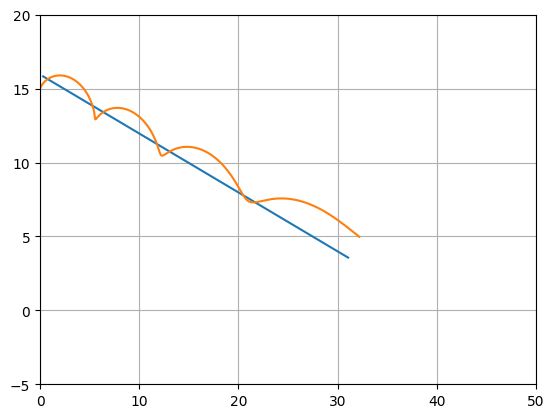

In [6]:

def electric_field(pos, args):
    L_star, f0 = args
    poses = np.reshape(pos, (-1, pos.shape[-1]))

    dx = L_star - poses[:, 0]
    r2 = dx**2 + poses[:, 1]**2 + 1e-16
    Exs = f0 * poses[:, 1] / r2
    Eys = f0 * dx / r2
    return np.array((Exs, Eys), "float").T

y0 = 0.15
L_star = 0.4
f0 = 70
T = 0.25 / 1000


omega_c = q * B / m
Tgyro = 2*np.pi / omega_c
dt = Tgyro / 50
N_steps = int(T / dt)

x0s = np.array([[0, y0, 0]], "float")
v0s = np.array([[0, 0, 0]], "float")

ef_args = (L_star, f0)

trajectory = simulate_boris(dt, N_steps, x0s, v0s, ef_args)[0]

gc_drift = simulate_gc(dt, N_steps, x0s, v0s, ef_args)[0]

plt.plot(*gc_drift.T * 100)
plt.plot(*trajectory.T * 100)
plt.grid()
plt.xlim(0, 50)
plt.ylim(-5, 20)
plt.show()

In [9]:
import scipy.optimize

def electric_field(pos, args):
    Ex, Ey, a = args
    poses = np.reshape(pos, (-1, pos.shape[-1]))
    Es = np.empty((len(poses), 2))
    Es[:, 0] = Ex
    Es[:, 1] = Ey * (1 + a * poses[:, 0])
    return Es



m = 3.44e-25



x0s = np.array([[0, 0, 0]], "float")

%matplotlib inline

from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np


def plot_simulation(vx=0, vy=0, E=500, alpha=0, xlim=100):
    v0s = np.array([[vx, vy, 0]], "float")

    omega_c = q * B / m
    Tgyro = 2*np.pi / omega_c
    N_gyro = 30
    T = N_gyro * Tgyro
    n_gyro = 100
    dt = Tgyro / n_gyro
    N_steps = round(T / dt)

    ef_args = [0, E]
    v_drift = np.cross(np.array([*ef_args[:2], 0]), np.array([0, 0, B])) / (B**2)

    v_gyro = np.array([vx, vy, 0]) - v_drift

    rL = np.linalg.norm(np.cross(v_gyro, np.array([0, 0, B])) / (omega_c * B))

    ef_args.append(alpha / rL)
    #print(alpha / rL)
    
    
    trajectory = simulate_boris(dt, N_steps, x0s, v0s, ef_args)[0]
    gc_drift = simulate_gc(dt, N_steps, x0s, v0s, ef_args)[0]

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].plot(*gc_drift.T * 100)
    axs[0].plot(*trajectory.T * 100)
    #axs[0].plot(gc_drift[:, 0] * 100, (gc_drift[0, 1] + E * alpha / rL / 2 / B**2 * gc_drift[:, 0]) * 100)
    axs[0].plot(*(trajectory.reshape((N_gyro, n_gyro, 2)).mean(axis=1).T * 100), 'ro')

    axs[0].plot(*np.array([gc_drift[:, 0], gc_drift[0, 1] + alpha * gc_drift[:, 0]]) * 100, "k--")

    axs[0].set_xlim((trajectory[:, 0].min()*100 - 0.05 * xlim, xlim))
    i_stop = np.argmax(trajectory[:, 0] > xlim / 100)
    if i_stop == 0:
        i_stop = len(trajectory) + 1
    ymax = trajectory[:i_stop, 1].max()
    ymin = trajectory[:i_stop, 1].min()
    axs[0].set_ylim((ymin * 100, ymax*1.1 * 100))


    #print(np.round(trajectory.reshape((N_gyro, n_gyro, 2)).mean(axis=1), 4))
    #print(scipy.optimize.curve_fit(lambda x, a, b: a * x + b, *trajectory.reshape((N_gyro, n_gyro, 2)).mean(axis=1).T))
    axs[1].plot(*(trajectory - np.array([gc_drift[:, 0], gc_drift[0, 1] + alpha * gc_drift[:, 0]]).T).T[:, :i_stop] * 100)
    lim = (-rL * 1.1 * 100, rL * 1.1 * 100)
    axs[1].set_xlim(lim)
    axs[1].set_ylim(lim)
    axs[1].text(0.98, 0.98, f"$\\rho_L$ = {rL*100:.2f} cm",
        transform=axs[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    #plt.text()

    
    #axs[0].set_ylim((trajectory[:, 1].min()*0.975*100, trajectory[:, 1].max()*1.025*100))
    

    for ax in axs[:2]:
        ax.grid()
        #ax.set_ylim((-8, 8))
        ax.set_xlabel("x, cm")
        ax.set_ylabel("y, cm")

    xs = np.linspace(trajectory[:, 0].min(), min(trajectory[:, 0].max(), xlim/100), 100).reshape((-1, 1))
    #print(xs[-1])
    es = electric_field(xs, ef_args)[:, 1]
    axs[2].plot(xs * 100, es)
    axs[2].set_xlabel("x, cm")
    axs[2].set_ylabel("Ey, V/m")
    axs[2].grid()
    axs[2].set_xlim((-10, xlim))
    axs[2].set_ylim((0, es.max()*1.1))

    fig.tight_layout()
    plt.show()
    #print(rL * 100)
    #print(m / q / B * np.sqrt((np.abs(vx) - E/B)**2 + vy**2) * 100)
    #print(0.5 * 100 * (np.max(trajectory[:, 1]) - np.min(trajectory[:, 1])))

interact(
    plot_simulation,
    vx=(-5000, 5000, 100),
    vy=(-5000, 5000, 100),
    E=(100, 1000, 10),
    alpha=(0, 1, 0.01),
    xlim=(20, 400, 20)
);

interactive(children=(IntSlider(value=0, description='vx', max=5000, min=-5000, step=100), IntSlider(value=0, …

![alt text](image.png)

In [8]:
def electric_field(pos, args):
    Ex, Ey, a = args
    print(pos.shape)
    poses = np.reshape(pos, (-1, pos.shape[-1]))
    print(poses.shape)
    Es = np.empty((len(poses), 2))
    Es[:, 0] = Ex
    Es[:, 1] = Ey * (1 + a * poses[:, 0])
    return Es


xs = np.linspace(0, 1, 5).reshape((-1, 1))
electric_field(xs, (0, 500, 0.01))[:, 1]

(5, 1)
(5, 1)


array([500.  , 501.25, 502.5 , 503.75, 505.  ])